이 노트북을 실행하는 데 필요한 라이브러리(표준 라이브러리 제외)
- torch
- numpy
- matplotlib
- datasets
- peft
- transformers

# QLoRA — 예제 노트북

심화 학습 자료 [`README.md`](README.md)의 실습 코드를 담았다.

- 12-3절의 4비트 양자화 위에 LoRA 어댑터를 얹어, 자연어 발화를 함수 호출 JSON으로 바꾸는 작업에 미세 조정한다.
- 절 번호는 `README.md`와 같다. 1~3절의 이론은 문서를 참고하자.
- **NVIDIA GPU(CUDA)가 필요하다.** `bitsandbytes` 양자화는 CUDA에 최적화되어 있다.

## 준비 — 환경 설정과 양자화 설정

In [1]:
# 환경 설정 (code_reference 모듈 임포트 경로와 시각화 설정)
import sys
sys.path.append('../../')

from code_reference import common
from code_reference import visualize as viz

common.set_korean_plot_env()
viz.configure(save_grayscale=False)

SEED = 42
common.set_seed(SEED, deterministic=True)
device = common.get_device()

CUDA를 사용합니다.


- 양자화 설정 객체는 12-3절 [코드 12-13]과 같다. 모델은 4절에서 이 설정으로 불러온다.

In [2]:
# 4비트 양자화 설정 객체와 토크나이저
#   양자화 설정의 인자별 의미는 12-3절 [코드 12-13]과 README 3절을 참고
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

MODEL_NAME = 'Bllossom/llama-3.2-Korean-Bllossom-3B'

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,                      # 4비트로 모델 가중치 로드
    bnb_4bit_quant_type='nf4',              # NF4 형식 사용
    bnb_4bit_compute_dtype=torch.float16,   # 행렬곱 계산은 FP16으로
    bnb_4bit_use_double_quant=True,         # 양자화 상수도 한 번 더 양자화
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

/home/crapas/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 4. 실습 — 자연어를 함수 호출로 바꾸기

### 4.1 문제

- 사용자 발화를 함수 호출 JSON으로 바꾸는 작업이다. 함수 일곱 개를 스키마로 정의하고, 시스템 프롬프트로 출력 형식을 지시한다.
- 3B 모델도 JSON 형식은 잘 지킨다. 문제는 **인자 값을 제멋대로 해석한다**는 점이다.
    - '글피'를 날짜로 계산해 버리거나, '뉴진스'를 영어로 옮겨 적는다.
- 학습으로 심으려는 것은 지식이 아니라 **"알아서 해석하지 말고 그대로 받아 적으라"는 행동 규칙**이다.

In [3]:
# 함수 스키마와 시스템 프롬프트 정의
import json
import random
import re

# 함수 스키마: 모델이 골라야 할 함수 7개를 한 dict로 묶는다.
FUNCTIONS = {
    'create_event': {'desc': '캘린더에 일정 추가',
                     'required': ['date', 'time', 'title']},
    'set_reminder': {'desc': '특정 시각에 알림',
                     'required': ['time', 'message']},
    'get_weather':  {'desc': '도시 날씨 조회',
                     'required': ['city'], 'optional': ['date']},
    'send_message': {'desc': '특정 사람에게 메시지 전송',
                     'required': ['recipient', 'content']},
    'play_music':   {'desc': '음악 재생',
                     'required': ['query']},
    'set_alarm':    {'desc': '알람 설정',
                     'required': ['time'], 'optional': ['label']},
    'search_web':   {'desc': '웹 검색',
                     'required': ['query']},
}


def build_system_prompt():
    """FUNCTIONS dict를 시스템 프롬프트 문자열로 변환한다."""
    lines = [
        '당신은 사용자 요청을 함수 호출 JSON으로 변환하는 어시스턴트입니다.',
        '응답은 반드시 단 하나의 JSON 객체만 출력합니다. '
        '설명·인사·줄바꿈을 포함하지 않습니다.',
        '',
        '사용 가능한 함수:',
    ]
    for name, spec in FUNCTIONS.items():
        args = ', '.join(spec['required'])
        if 'optional' in spec:
            args += ', ' + ', '.join(f'{a}?' for a in spec['optional'])
        lines.append(f'- {name}({args}): {spec["desc"]}')
    lines.append('')
    lines.append('응답 형식: {"function": "함수명", "args": {"key": "value", ...}}')
    return '\n'.join(lines)


SYSTEM_PROMPT = build_system_prompt()
print(SYSTEM_PROMPT)

당신은 사용자 요청을 함수 호출 JSON으로 변환하는 어시스턴트입니다.
응답은 반드시 단 하나의 JSON 객체만 출력합니다. 설명·인사·줄바꿈을 포함하지 않습니다.

사용 가능한 함수:
- create_event(date, time, title): 캘린더에 일정 추가
- set_reminder(time, message): 특정 시각에 알림
- get_weather(city, date?): 도시 날씨 조회
- send_message(recipient, content): 특정 사람에게 메시지 전송
- play_music(query): 음악 재생
- set_alarm(time, label?): 알람 설정
- search_web(query): 웹 검색

응답 형식: {"function": "함수명", "args": {"key": "value", ...}}


### 4.2 학습 데이터 합성

- 함수별 표면 표현 템플릿과 슬롯 풀(시각, 도시, 인물, 곡명 등)을 조합해 (사용자 발화, 정답 JSON) 쌍을 만든다.
    - 실무에서도 규칙이 분명한 작업은 이렇게 데이터를 합성해 시작하는 경우가 많다.

In [4]:
# 함수 호출 학습·평가 데이터 합성
# 슬롯 풀: 각 인자 자리에 들어갈 후보 값들
TIMES = ['오전 7시', '오전 9시', '오전 10시 30분', '오전 11시',
         '오후 1시', '오후 2시 15분', '오후 3시', '오후 5시',
         '저녁 7시', '저녁 8시 30분', '밤 10시', '밤 11시']
DATES = ['오늘', '내일', '모레', '글피', '이번 주 토요일',
         '다음 주 월요일', '다음 주 금요일', '5월 28일', '6월 3일', '6월 15일']
CITIES = ['서울', '부산', '대구', '인천', '광주',
          '대전', '울산', '제주', '강릉', '전주']
PEOPLE = ['김 부장님', '이 과장님', '박 대리', '최 팀장님',
          '엄마', '아빠', '동생', '수진이', '준호', '지민이']
EVENTS = ['팀 회의', '점심 약속', '치과 예약', '저녁 식사',
          '발표 준비', '운동', '독서 모임', '병원 진료']
MESSAGES_REMIND = ['회의 자료 챙기기', '약 먹기', '우산 챙기기',
                   '카드 결제 확인', '엄마한테 전화하기', '커피 사 오기']
SONGS = ['아이유 신곡', '오아시스의 Wonderwall', '클래식 피아노 음악',
         '잔잔한 재즈', 'BTS Dynamite', '뉴진스 노래', '비 오는 날 음악']
QUERIES = ['파이썬 데코레이터 사용법', '제주도 흑돼지 맛집', '오늘 환율 정보',
           '내일 야구 경기 결과', '서울 카페 추천', '딥러닝 기초 강의',
           '리눅스 셸 명령어']
MSG_CONTENTS = ['오늘 회의 좀 늦을 것 같아', '저녁 같이 먹을래?',
                '내일 일정 변경 가능?', '주말에 시간 어때?',
                '확인 부탁드립니다', '자료 받았습니다 감사합니다']
ALARM_LABELS = ['기상', '약 복용', '회의 알림', '운동 시작', '저녁 약속']

# 학습용 템플릿: 함수당 4종의 표면 표현
TRAIN_TEMPLATES = {
    'create_event': ['{date} {time}에 "{title}" 일정 잡아 줘',
                     '{date} {time} {title} 일정 추가해 줘',
                     '캘린더에 {date} {time}, {title} 등록해 줘',
                     '{title}을 {date} {time}에 일정으로 넣어 줘'],
    'set_reminder': ['{time}에 "{message}" 알림 보내 줘',
                     '{time}에 {message} 잊지 않게 알려 줘',
                     '{message} 알람 {time}에 맞춰 줘',
                     '{time}이 되면 {message} 알려 주세요'],
    'get_weather': ['{city} 날씨 알려 줘', '{date} {city} 날씨 어때?',
                    '{city}의 {date} 날씨가 궁금해', '{date} {city} 비 오나?'],
    'send_message': ['{recipient}한테 "{content}" 라고 메시지 보내 줘',
                     '{recipient}에게 {content} 전해 줘',
                     '{recipient}한테 메시지 보낼래: {content}',
                     '{content}이라고 {recipient}에게 전송해 줘'],
    'play_music': ['{query} 틀어 줘', '{query} 재생해 줘',
                   '{query} 좀 들려줘', '{query} 듣고 싶어'],
    'set_alarm': ['{time}에 알람 맞춰 줘', '{time}에 {label} 알람 설정해 줘',
                  '내일 {time} 알람 부탁해', '{time}에 {label} 깨워 줘'],
    'search_web': ['{query} 검색해 줘', '{query} 찾아 줘',
                   '{query} 정보 알아봐 줘', '{query}에 대해 검색해 봐'],
}

# 평가용 템플릿: 학습과 겹치지 않는 별개 표현
EVAL_TEMPLATES = {
    'create_event': ['{date} {time}부터 {title} 잡아 둘래?',
                     '이번에 {date} {time}에 {title} 있는데 캘린더 부탁해'],
    'set_reminder': ['{time}이 되면 {message} 알리도록 해 줘',
                     '나 {time}에 {message} 까먹지 말게 좀 챙겨 줘'],
    'get_weather': ['{city} 오늘 우산 필요한가?',
                    '{date} {city} 기온 알려 주실래요?'],
    'send_message': ['{recipient}한테 "{content}" 보내려고 하는데',
                     '{recipient}에게 "{content}" 라고 카톡 좀'],
    'play_music': ['{query} 좀 들어 보고 싶은데',
                   '지금 분위기에 {query} 어울릴 듯'],
    'set_alarm': ['{time}에 일어나야 해 알람 좀', '{time} {label}로 알람 부탁'],
    'search_web': ['{query} 한 번 찾아 봐 줄래?', '{query} 관련해서 좀 알아봐'],
}


def gen_sample(func_name, templates):
    """함수 이름과 템플릿을 받아 (USER 발화, GOLD JSON dict) 쌍을 반환."""
    tpl = random.choice(templates[func_name])
    if func_name == 'create_event':
        date, time, title = (random.choice(DATES), random.choice(TIMES),
                             random.choice(EVENTS))
        user = tpl.format(date=date, time=time, title=title)
        args = {'date': date, 'time': time, 'title': title}
    elif func_name == 'set_reminder':
        time, msg = random.choice(TIMES), random.choice(MESSAGES_REMIND)
        user = tpl.format(time=time, message=msg)
        args = {'time': time, 'message': msg}
    elif func_name == 'get_weather':
        city = random.choice(CITIES)
        date = random.choice(DATES) if '{date}' in tpl else None
        user = tpl.format(city=city, date=date or '')
        args = {'city': city}
        if date is not None:
            args['date'] = date
    elif func_name == 'send_message':
        recipient, content = random.choice(PEOPLE), random.choice(MSG_CONTENTS)
        user = tpl.format(recipient=recipient, content=content)
        args = {'recipient': recipient, 'content': content}
    elif func_name == 'play_music':
        query = random.choice(SONGS)
        user = tpl.format(query=query)
        args = {'query': query}
    elif func_name == 'set_alarm':
        time = random.choice(TIMES)
        label = random.choice(ALARM_LABELS) if '{label}' in tpl else None
        user = tpl.format(time=time, label=label or '')
        args = {'time': time}
        if label is not None:
            args['label'] = label
    elif func_name == 'search_web':
        query = random.choice(QUERIES)
        user = tpl.format(query=query)
        args = {'query': query}
    return user, {'function': func_name, 'args': args}


def make_dataset(templates, n_per_func):
    """함수별 n_per_func건씩 생성해 셔플한 list를 반환."""
    samples = []
    for fname in FUNCTIONS:
        for _ in range(n_per_func):
            user, gold = gen_sample(fname, templates)
            samples.append({'user': user,
                            'assistant': json.dumps(gold, ensure_ascii=False)})
    random.shuffle(samples)
    return samples


train_samples = make_dataset(TRAIN_TEMPLATES, n_per_func=22)
eval_samples = make_dataset(EVAL_TEMPLATES, n_per_func=3)
print(f'학습 샘플: {len(train_samples)}건 / 평가 샘플: {len(eval_samples)}건')
for s in train_samples[:2]:
    print(f'  USER : {s["user"]}')
    print(f'  GOLD : {s["assistant"]}')

학습 샘플: 154건 / 평가 샘플: 21건
  USER : 내일 야구 경기 결과 찾아 줘
  GOLD : {"function": "search_web", "args": {"query": "내일 야구 경기 결과"}}
  USER : 글피 오전 10시 30분 점심 약속 일정 추가해 줘
  GOLD : {"function": "create_event", "args": {"date": "글피", "time": "오전 10시 30분", "title": "점심 약속"}}


### 4.3 추론 헬퍼와 채점 함수

- 평가용 추론은 그리디 디코딩(`do_sample=False`)을 사용한다.
    - 어댑터 OFF와 ON을 비교할 때 생성의 무작위성을 배제하기 위해서다.
- 채점은 세 단계로 나눈다. JSON 파싱 성공, 함수 이름 일치, 인자 값 완전 일치.

In [5]:
# 함수 호출 추론 헬퍼와 채점 함수
TERMINATORS = [
    tokenizer.convert_tokens_to_ids('<|end_of_text|>'),
    tokenizer.convert_tokens_to_ids('<|eot_id|>'),
]
MAX_INPUT_LEN = 512


def generate_funccall(user_text, model, max_new_tokens=128):
    """함수 호출 평가 전용 추론 헬퍼 (그리디 디코딩)."""
    messages = [
        {'role': 'system', 'content': SYSTEM_PROMPT},
        {'role': 'user', 'content': user_text},
    ]
    input_ids = tokenizer.apply_chat_template(
        messages, add_generation_prompt=True,
        return_tensors='pt', return_dict=False,
        truncation=True, max_length=MAX_INPUT_LEN,
    ).to(model.device)
    with torch.no_grad():
        output_ids = model.generate(
            input_ids, max_new_tokens=max_new_tokens,
            eos_token_id=TERMINATORS, do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )
    return tokenizer.decode(
        output_ids[0][input_ids.shape[-1]:], skip_special_tokens=True,
    ).strip()


def try_extract_json(text):
    """모델 출력에서 가장 바깥의 JSON 객체 한 개를 뽑는다."""
    m = re.search(r'\{.*\}', text, re.DOTALL)
    if not m:
        return None
    try:
        return json.loads(m.group(0))
    except json.JSONDecodeError:
        return None


def score_one(pred_text, gold):
    """한 샘플 채점: parse / func_ok / args_ok."""
    pred = try_extract_json(pred_text)
    gold_obj = json.loads(gold)
    if pred is None:
        return {'parse': False, 'func_ok': False, 'args_ok': False}
    func_ok = pred.get('function') == gold_obj['function']
    args_ok = func_ok and pred.get('args') == gold_obj['args']
    return {'parse': True, 'func_ok': func_ok, 'args_ok': args_ok}


def evaluate(model, samples, label):
    """여러 샘플을 순회하며 세 지표를 합산하고 (rows, stats)를 반환."""
    stats = {'parse': 0, 'func_ok': 0, 'args_ok': 0}
    rows = []
    for s in samples:
        out = generate_funccall(s['user'], model)
        sc = score_one(out, s['assistant'])
        for k in stats:
            stats[k] += int(sc[k])
        rows.append((s['user'], s['assistant'], out, sc))
    n = len(samples)
    print(f'[{label}] n={n} '
          f'JSON parse {stats["parse"]}/{n}, '
          f'function {stats["func_ok"]}/{n}, '
          f'args 완전일치 {stats["args_ok"]}/{n}')
    return rows, stats

### 4.4 −100 마스킹

- 시스템 프롬프트와 사용자 발화는 '입력 부분', 정답 JSON은 '정답 부분'이다.
- 디코더 전용 모델은 둘을 이어 붙여 하나의 시퀀스로 학습한다.
    - 그런데 입력 부분까지 맞히도록 학습하면 안 된다. 모델이 배워야 할 것은 정답 JSON을 내놓는 방법이다.
    - 그래서 입력 부분의 레이블을 `-100`으로 채워 손실 계산에서 제외한다. 교차 엔트로피 손실 함수의 `ignore_index` 기본값이 `-100`이다.

In [6]:
# 함수 호출 합성 데이터를 LLaMA 입력 형식으로 가공
from datasets import Dataset
from transformers import DataCollatorForSeq2Seq

MAX_TARGET_LEN = 160

# LLaMA 토크나이저는 left 패딩이 기본(생성에 적합). 학습에는 right 패딩을 쓴다.
tokenizer.padding_side = 'right'
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token


def tokenize_example(ex):
    """한 샘플 -> {'input_ids', 'labels', 'attention_mask'}."""
    messages = [
        {'role': 'system', 'content': SYSTEM_PROMPT},
        {'role': 'user', 'content': ex['user']},
    ]
    prompt_ids = tokenizer.apply_chat_template(
        messages, add_generation_prompt=True,
        return_tensors=None, return_dict=False,
        truncation=True, max_length=MAX_INPUT_LEN,
    )
    target_text = ex['assistant'] + tokenizer.eos_token
    target_ids = tokenizer(
        target_text, add_special_tokens=False,
        truncation=True, max_length=MAX_TARGET_LEN,
    )['input_ids']
    input_ids = prompt_ids + target_ids
    # 입력 토큰 자리는 -100으로 마스킹 -> 손실에서 제외, 정답 토큰만 학습.
    labels = [-100] * len(prompt_ids) + target_ids
    return {'input_ids': input_ids, 'labels': labels,
            'attention_mask': [1] * len(input_ids)}


tokenized_train = Dataset.from_list(train_samples).map(
    tokenize_example, remove_columns=['user', 'assistant'],
)
print(f'토크나이즈 완료. 첫 샘플 길이: '
      f'{len(tokenized_train[0]["input_ids"])} 토큰')

# DataCollatorForSeq2Seq: 가변 길이 input_ids·labels를 함께 패딩.
# (DataCollatorForLanguageModeling은 labels를 input_ids로 덮어써 -100과 충돌)
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer, padding='longest', label_pad_token_id=-100,
)

Map:   0%|          | 0/154 [00:00<?, ? examples/s]

Map:  67%|██████▋   | 103/154 [00:00<00:00, 1017.28 examples/s]

Map: 100%|██████████| 154/154 [00:00<00:00, 962.46 examples/s] 

토크나이즈 완료. 첫 샘플 길이: 237 토큰


## 3. 양자화를 얹으면 — QLoRA 모델 준비

- QLoRA는 네 단계로 준비한다.
    1. 4비트 양자화로 사전 학습 모델을 불러온다.
    2. `prepare_model_for_kbit_training()`으로 학습 가능한 상태로 전환한다. 양자화 모델에 어댑터를 붙이기 전에 반드시 거쳐야 하는 단계다.
    3. `get_peft_model()`로 LoRA 어댑터를 추가한다.
    4. `print_trainable_parameters()`로 학습 대상을 확인한다.
- 결과를 가르는 인자는 셋이다(README 2.3절).
    - `r`: 저랭크 분해 차원. 클수록 표현력이 늘지만 어댑터도 커진다.
    - `lora_alpha`: 스케일 계수. 실효 배율은 `lora_alpha / r`이다.
    - `target_modules`: 어댑터를 붙일 계층. 여기서는 어텐션의 Q, V 선형 계층에만 붙인다.

In [7]:
# QLoRA 모델 준비
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

# (1) 4비트 양자화로 사전 학습 모델 로드
model = AutoModelForCausalLM.from_pretrained(
    'Bllossom/llama-3.2-Korean-Bllossom-3B',
    quantization_config=bnb_config,         # [코드 12-14] 참조
    device_map='auto',
)
# (2) 양자화 모델을 학습 가능 상태로 전환
model = prepare_model_for_kbit_training(model)

# (3) LoRA 어댑터 계층 추가
lora_config = LoraConfig(                   # LoRA 설정 객체 생성
    r=16,                                   # 저랭크 분해 차원
    lora_alpha=32,                          # LoRA 스케일 계수 (alpha / r)
    target_modules=['q_proj', 'v_proj'],    # 어텐션의 Q, V 선형 계층에만 적용
    lora_dropout=0.05,
    bias='none',
    task_type='CAUSAL_LM',                  # 인과언어모델 (LLaMA, GPT 등)
)
# LoRA 설정 객체를 사용해 모델에 LoRA 어댑터 계층 추가
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

Loading weights:   0%|          | 1/254 [00:00<01:45,  2.40it/s]

Loading weights:   1%|          | 3/254 [00:00<00:40,  6.17it/s]

Loading weights:   5%|▍         | 12/254 [00:00<00:09, 25.80it/s]

Loading weights:   7%|▋         | 17/254 [00:00<00:07, 30.85it/s]

...

Loading weights:  91%|█████████ | 230/254 [00:03<00:00, 78.95it/s]

Loading weights:  94%|█████████▍| 239/254 [00:04<00:00, 81.70it/s]

Loading weights:  98%|█████████▊| 248/254 [00:04<00:00, 82.64it/s]

Loading weights: 100%|██████████| 254/254 [00:04<00:00, 60.29it/s]

trainable params: 4,587,520 || all params: 3,217,337,344 || trainable%: 0.1426


## 4.5 학습 설정과 학습

- 짚고 갈 것이 셋이다.
    - **패딩 방향을 바꾼다.** Llama 계열 토크나이저는 패딩을 왼쪽에 두는 것이 기본인데, 학습할 때는 오른쪽 패딩이 맞다. 인과 마스크가 왼쪽부터 순서대로 동작하므로 패딩이 앞에 끼면 위치가 밀린다.
    - **학습률이 크다.** `2e-4`는 일반적인 미세 조정 기본값 `5e-5`의 네 배다. 학습 대상이 어댑터로 한정되어 있고 어댑터는 0에서 출발하므로, 과감하게 움직여도 사전 학습 성능이 무너지지 않는다.
    - **기울기 누적으로 배치를 키운다.** 한 번에 다루는 샘플은 2개지만 네 번 모아 갱신하므로 배치 8의 효과를 낸다.

In [8]:
# QLoRA 학습 엔진 생성 및 학습 실행
from transformers import TrainingArguments, Trainer

# 학습 시에는 인과 마스크가 자연스럽게 동작하도록 right 패딩을 사용한다.
tokenizer.padding_side = 'right'

training_args = TrainingArguments(          # 학습 설정 객체
    output_dir='../../checkpoint/qlora-funccall',
    num_train_epochs=3,                     # 154건짜리 작은 데이터라 3 에포크
    per_device_train_batch_size=2,          # 가속기 장치별 배치 크기 2
    gradient_accumulation_steps=4,          # 4 배치마다 1회 최적화 (실효 배치 8)
    learning_rate=2e-4,                     # LoRA, QLoRA 권장 수준
    fp16=True,                              # LoRA 어댑터, 옵티마이저 연산 자료형
    save_strategy='no',
    report_to='none',
    logging_steps=5,                        # 학습 로그 출력 빈도
    seed=42,
)

trainer = Trainer(
    model=model, args=training_args,
    train_dataset=tokenized_train,          # 함수 호출용 합성 데이터셋
    data_collator=data_collator,
)
# Trainer가 네이티브 학습 로그를 직접 출력한다. 직접 에포크 print는 만들지 않고,
# 반환된 metrics의 train_runtime으로 전체 학습 시간만 사람이 읽기 좋게 출력한다(§7.7).
result = trainer.train()
print(f'전체 학습 시간: {result.metrics["train_runtime"]:.1f}초')

# 학습이 끝나면 어댑터만 저장한다 (사전 학습 가중치는 저장하지 않는다)
model.save_pretrained('../../checkpoint/qlora-funccall/adapter')
# 다시 불러올 때는 PeftModel.from_pretrained(base_model, '어댑터 경로') 사용

/home/crapas/.local/lib/python3.12/site-packages/torch/_dynamo/eval_frame.py:838: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss
5,0.187351
10,0.042555
15,0.029324
20,0.033593
25,0.011525
30,0.010781
35,0.007309
40,0.006001
45,0.005662
50,0.005110


전체 학습 시간: 363.1초


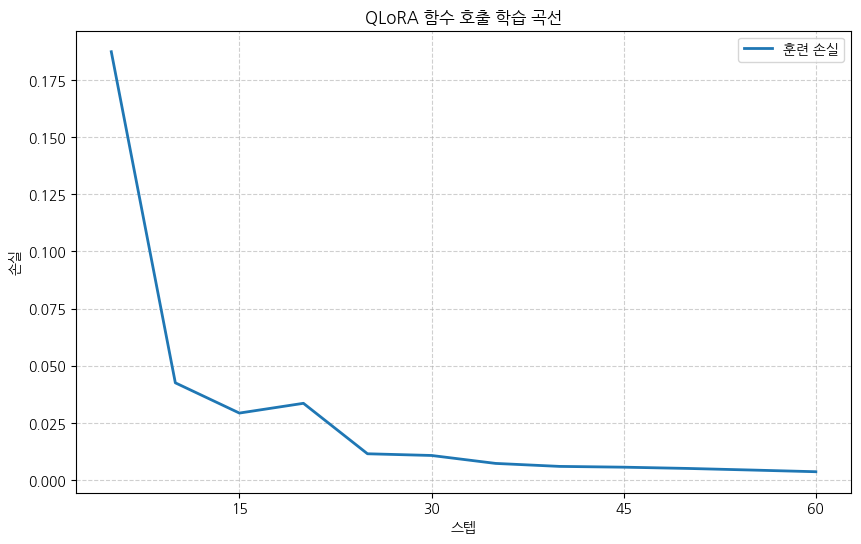

In [9]:
# 참고 - log_history에서 훈련 손실을 뽑아 학습 곡선을 그린다 (§7.7)
train_curve = [(rec['step'], rec['loss'])
               for rec in trainer.state.log_history if 'loss' in rec]

viz.plot_history(
    train_curve, label='훈련 손실',
    title='QLoRA 함수 호출 학습 곡선', x_label='스텝', y_label='손실',
)

## 5. 결과 읽기 — 어댑터를 켜고 끄기

- LoRA의 성질 하나가 평가를 편하게 만든다. **어댑터는 원래 계층 옆에 덧붙은 경로일 뿐이므로, 끄면 원래 모델이 된다.**
    - 같은 모델 객체 하나로 학습 전후를 비교할 수 있다. 모델을 두 번 불러올 필요가 없다.

In [10]:
# LoRA 어댑터 계층 활성화/비활성화별 모델 평가
model.eval()

# 어댑터 계층 비활성화 (미세 조정 전 양자화 모델 추론)
print('### 어댑터 계층 비활성화')
with model.disable_adapter():
    off_rows, off_stats = evaluate(model, eval_samples, '어댑터 OFF')

# 어댑터 계층 활성화 (QLoRA 미세 조정 적용 양자화 모델 추론)
print('### 어댑터 계층 활성화')
on_rows, on_stats = evaluate(model, eval_samples, '어댑터 ON')

[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


### 어댑터 계층 비활성화


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


[어댑터 OFF] n=21 JSON parse 21/21, function 18/21, args 완전일치 6/21
### 어댑터 계층 활성화


[어댑터 ON] n=21 JSON parse 21/21, function 21/21, args 완전일치 18/21


- README 5절의 결과는 다음과 같다(평가 데이터 21건).

| 기준 | 어댑터 OFF | 어댑터 ON |
|---|---|---|
| JSON 파싱 성공 | 21 / 21 | 21 / 21 |
| 함수 이름 일치 | 18 / 21 | 21 / 21 |
| 인자 값 완전 일치 | 5 / 21 (24%) | 18 / 21 (86%) |

- JSON 형식은 처음부터 완벽하다. 시스템 프롬프트가 형식을 강하게 지시하고, 3B 모델도 그 정도는 따른다.
- 차이는 인자 값에서 난다. 실제 출력을 나란히 놓고 확인해 보자.

In [11]:
# 앞 3건을 어댑터 OFF와 ON으로 나란히 출력
for i in range(3):
    user, gold, _, _ = on_rows[i]
    print(f'\nUSER : {user}')
    print(f'GOLD : {gold}')
    print(f'OFF  : {off_rows[i][2][:200]}')
    print(f'ON   : {on_rows[i][2][:200]}')


USER : 글피 오전 9시부터 독서 모임 잡아 둘래?
GOLD : {"function": "create_event", "args": {"date": "글피", "time": "오전 9시", "title": "독서 모임"}}
OFF  : {"function": "create_event", "args": {"date": "2024-03-16", "time": "09:00", "title": "독서 모임"}}
ON   : {"function": "create_event", "args": {"date": "글피", "time": "오전 9시", "title": "독서 모임"}}

USER : 준호에게 "자료 받았습니다 감사합니다" 라고 카톡 좀
GOLD : {"function": "send_message", "args": {"recipient": "준호", "content": "자료 받았습니다 감사합니다"}}
OFF  : {"function": "send_message", "args": {"recipient": "준호", "content": "자료 받았습니다 감사합니다"}}
ON   : {"function": "send_message", "args": {"recipient": "준호", "content": "자료 받았습니다 감사합니다"}}

USER : 오늘 제주 기온 알려 주실래요?
GOLD : {"function": "get_weather", "args": {"city": "제주", "date": "오늘"}}
OFF  : {"function": "get_weather", "args": {"city": "제주", "date": "오늘"}}
ON   : {"function": "get_weather", "args": {"city": "제주", "date": "오늘"}}


- 모델이 새로운 지식을 배운 것이 아니다. '글피'가 무엇인지도, '뉴진스'가 무엇인지도 원래 알고 있었다.
    - 바뀐 것은 행동 규칙뿐이고, 그 정도는 전체 파라미터의 0.14%짜리 어댑터로 충분하다.

## 6. 어댑터만 저장하기

- 학습이 끝나면 어댑터만 저장한다. 앞의 학습 셀에서 이미 저장했다.
    - 32억 개의 사전 학습 가중치는 저장하지 않는다. 459만 개의 어댑터 가중치만 담기므로 10MB 안팎이다.
- 작업마다 어댑터를 따로 학습해 두고 갈아 끼울 수 있다는 점이 실무에서 특히 유용하다.
    - 메모리에 사전 학습 모델을 한 번만 올려 두고 어댑터만 바꿔 끼우면 된다.

In [12]:
# 어댑터만 다시 불러오는 방법
#   사전 학습 모델을 불러온 뒤 어댑터를 얹는다. 어댑터는 10MB 안팎이다.
#
#   from peft import PeftModel
#   base_model = AutoModelForCausalLM.from_pretrained(
#       MODEL_NAME, quantization_config=bnb_config, device_map='auto',
#   )
#   model = PeftModel.from_pretrained(base_model, ADAPTER_DIR)

from pathlib import Path

ADAPTER_DIR = Path('../../checkpoint/qlora-funccall/adapter')
total_bytes = sum(p.stat().st_size for p in ADAPTER_DIR.glob('*') if p.is_file())
print(f'어댑터 디렉터리: {ADAPTER_DIR}')
for p in sorted(ADAPTER_DIR.glob('*')):
    if p.is_file():
        print(f'  {p.name:<28s} {p.stat().st_size / 1024:>10,.1f} KB')
print(f'합계: {total_bytes / 1024 / 1024:.2f} MB')

어댑터 디렉터리: ../../checkpoint/qlora-funccall/adapter
  README.md                           5.1 KB
  adapter_config.json                 1.0 KB
  adapter_model.safetensors      17,934.6 KB
합계: 17.52 MB


## 정리

- LoRA는 갱신할 파라미터를 전체의 0.14%로 줄이고, QLoRA는 거기에 4비트 양자화를 얹어 나머지가 차지하는 메모리마저 4분의 1로 줄인다.
- 양자화 모델에 어댑터를 붙이려면 `prepare_model_for_kbit_training()`을 먼저 거쳐야 한다.
- 입력 부분의 레이블을 `-100`으로 채워, 모델이 정답 부분만 학습하도록 한다.
- 어댑터를 끄면 원래 모델이 되므로, 같은 객체 하나로 학습 전후를 비교할 수 있다.
- 이 실습은 3B 모델이라 QLoRA가 꼭 필요하지는 않았다. 절차를 익히는 것이 목적이었고, 실제 이득은 7B 이상에서 나타난다.

연습 문제는 [`README.md`](README.md)의 연습 문제 절을 참고하자.